## Exploratory Data Analysis After Cluster
- After Clustering the customer into 5 Cluster we not stop, we process into deep down to see the exactly pattern and behavior of each type of customers to better provides the specific not generalize
### In this section we will:
- load two seperate dataset which is customer transaction & rfm_customer that we have cluster
- Count Number of Customers for each cluster
- Plot Avg of RFM base on each cluster
- Distribution & Revenue generate by each cluster
- The purchase behavior of customers in each cluster
- Finding on each section to final recommendation at the end of this notebook

In [1]:
#import library and ignore warning
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
#import dataset into dataframe

customers = pd.read_csv('../data/processed/online_retail_final.csv')
customers.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSpend,InvoiceYearMonth,InvoiceDateOnly,InvoiceDayOfWeek,InvoiceHour
0,536365,85123A,white hanging heart t-light holder,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010-12,2010-12-01,Wednesday,8
1,536365,71053,white metal lantern,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,2010-12-01,Wednesday,8
2,536365,84406B,cream cupid hearts coat hanger,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010-12,2010-12-01,Wednesday,8
3,536365,84029G,knitted union flag hot water bottle,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,2010-12-01,Wednesday,8
4,536365,84029E,red woolly hottie white heart.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,2010-12-01,Wednesday,8


In [3]:
rfm_customer = pd.read_csv("../data/cluster/online_retail_cluster.csv")
rfm_customer.head()

,CustomerID,Recency,Frequency,Monetary,RScore,FScore,MScore,Cluster,Description,Type
0,12346,326,1,77183.60,1,1,5,2,Moderately recent customers with good spending...,High Spenders
1,12347,2,7,4310.00,5,3,4,4,"Highly valuable customers: very recent, freque...",VIP
2,12348,75,4,1797.24,3,3,3,2,Moderately recent customers with good spending...,High Spenders
3,12349,19,1,1757.55,5,1,3,0,Very recent customers with moderate purchase f...,Active
4,12350,310,1,334.40,1,1,2,1,Old customers with very low frequency and low ...,Inactive


In [4]:
#convert to datetime
customers['InvoiceDate'] = pd.to_datetime(customers['InvoiceDate'])

# quick check
print(customers.shape)
print(rfm_customer.shape)

(392692, 13)
(4338, 10)


### Count customers per cluster

In [5]:
#Count customers per cluster
cluster_count = rfm_customer['Type'].value_counts().sort_index().reset_index()
cluster_count.columns = ['Cluster-Type', 'CustomerCount']
cluster_count

,Cluster-Type,CustomerCount
0,Active,929
1,High Spenders,695
2,Inactive,893
3,New/At Risk,1103
4,VIP,718


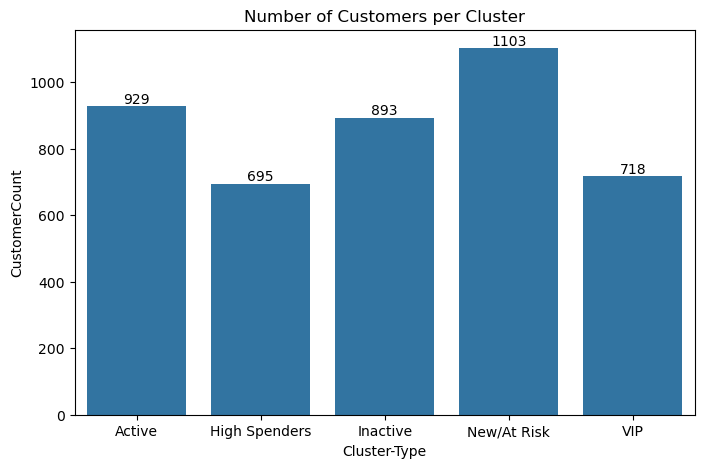

In [6]:
#plot the graph
plt.figure(figsize=(8,5))
ax = sns.barplot(data=cluster_count, x='Cluster-Type', y='CustomerCount')
for i in ax.containers:
    ax.bar_label(i)
plt.title('Number of Customers per Cluster')
plt.show()

### Average RFM by cluster using Type instead for easier to interpret

In [7]:
cluster_summary = rfm_customer.groupby('Type')[['Recency', 'Frequency', 'Monetary']].mean().round(2).reset_index()
cluster_summary

,Type,Recency,Frequency,Monetary
0,Active,18.63,4.07,1068.08
1,High Spenders,109.92,3.89,1726.39
2,Inactive,258.88,1.27,330.49
3,New/At Risk,58.93,1.31,361.76
4,VIP,16.07,13.20,8357.89


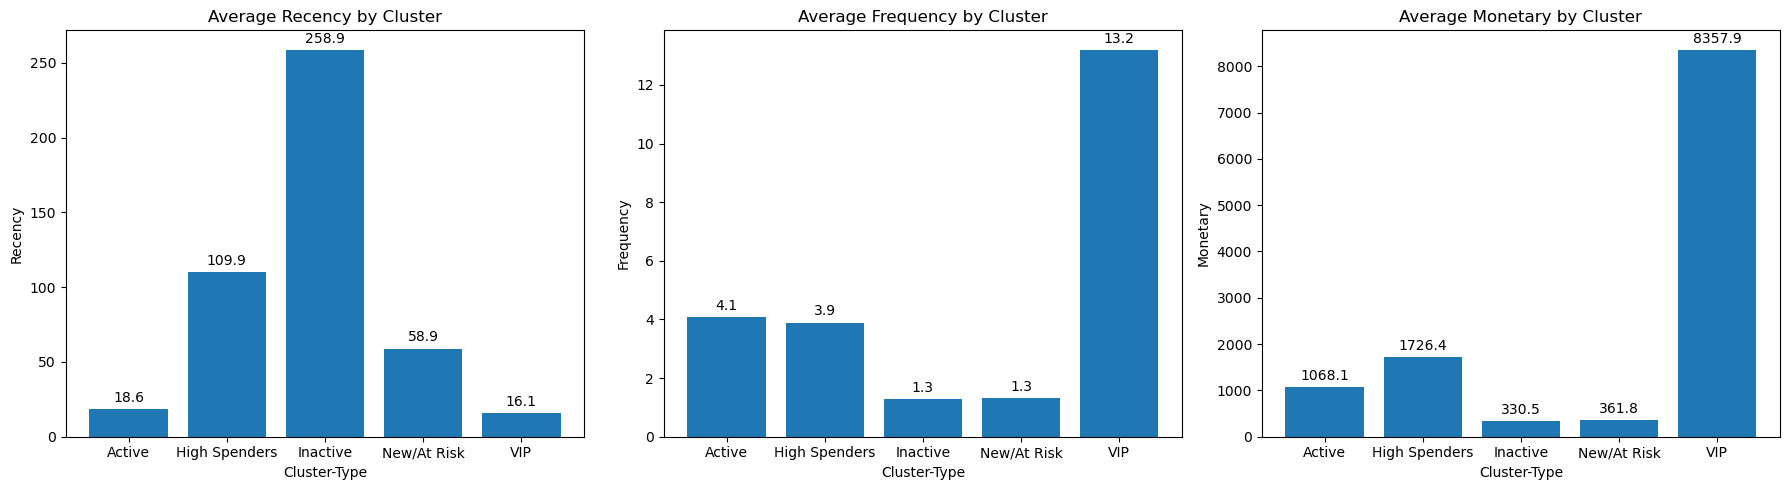

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

bars0 = axes[0].bar(cluster_summary['Type'], cluster_summary['Recency'])
axes[0].set_title('Average Recency by Cluster')
axes[0].set_xlabel('Cluster-Type')
axes[0].set_ylabel('Recency')
axes[0].bar_label(bars0, fmt='%.1f', padding=3)

bars1 = axes[1].bar(cluster_summary['Type'], cluster_summary['Frequency'])
axes[1].set_title('Average Frequency by Cluster')
axes[1].set_xlabel('Cluster-Type')
axes[1].set_ylabel('Frequency')
axes[1].bar_label(bars1, fmt='%.1f', padding=3)

bars2 = axes[2].bar(cluster_summary['Type'], cluster_summary['Monetary'])
axes[2].set_title('Average Monetary by Cluster')
axes[2].set_xlabel('Cluster-Type')
axes[2].set_ylabel('Monetary')
axes[2].bar_label(bars2, fmt='%.1f', padding=3)

plt.tight_layout()
plt.show()

It a contrast in Recency which mean that the lower it is the recent it is example
- Active user in average, Their last oders was around 19 days from last transaction day in records

### Distribution of each type cluster

In [10]:
rfm_customer.groupby('Type')[['Recency', 'Frequency', 'Monetary']].describe().round(2).T

Type              Active  High Spenders  Inactive  New/At Risk        VIP
Recency   count   929.00         695.00    893.00      1103.00     718.00
          mean     18.63         109.92    258.88        58.93      16.07
          std      12.68          58.17     64.81        37.31      15.21
          min       1.00          50.00    150.00         1.00       1.00
          25%       8.00          66.00    204.00        29.00       4.00
          50%      17.00          89.00    260.00        53.00      11.00
          75%      28.00         137.50    310.00        79.00      24.00
          max      49.00         372.00    374.00       149.00     114.00
Frequency count   929.00         695.00    893.00      1103.00     718.00
          mean      4.07           3.89      1.27         1.31      13.20
          std       2.26           2.31      0.59         0.49      15.53
          min       1.00           1.00      1.00         1.00       1.00
          25%       3.00           3.00      1.00         1.00       6.00
          50%       4.00           3.00      1.00         1.00      10.00
          75%       5.00           4.50      1.00         2.00      15.00
          max      39.00          34.00      6.00         4.00     209.00
Monetary  count   929.00         695.00    893.00      1103.00     718.00
          mean   1068.08        1726.39    330.49       361.76    8357.89
          std     509.07        3763.61    281.05       257.66   20611.61
          min      36.56         316.11      3.75         6.20    2000.86
          25%     679.45         781.94    154.99       181.08    2690.44
          50%    1005.09        1143.27    266.40       305.54    3959.45
          75%    1415.65        1889.07    405.38       477.88    6491.29
          max    3861.00       77183.60   2661.24      1862.00  280206.02

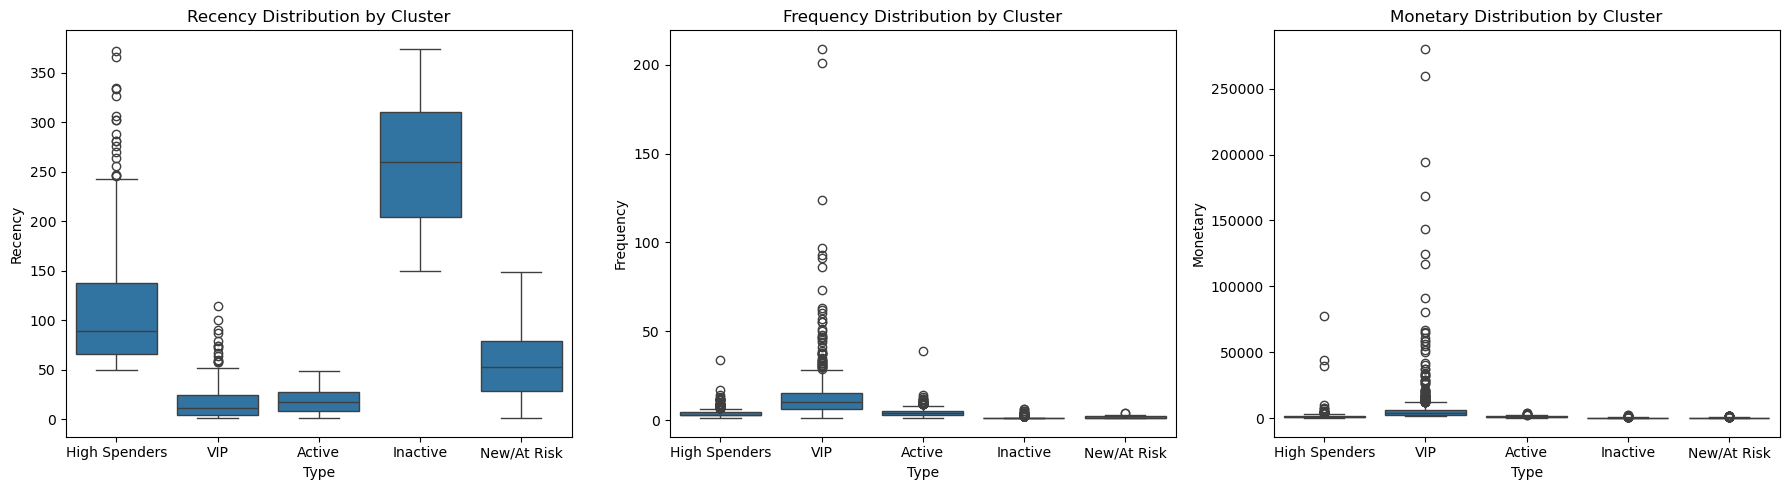

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.boxplot(data=rfm_customer, x='Type', y='Recency', ax=axes[0])
axes[0].set_title('Recency Distribution by Cluster')

sns.boxplot(data=rfm_customer, x='Type', y='Frequency', ax=axes[1])
axes[1].set_title('Frequency Distribution by Cluster')

sns.boxplot(data=rfm_customer, x='Type', y='Monetary', ax=axes[2])
axes[2].set_title('Monetary Distribution by Cluster')

plt.tight_layout()
plt.show()

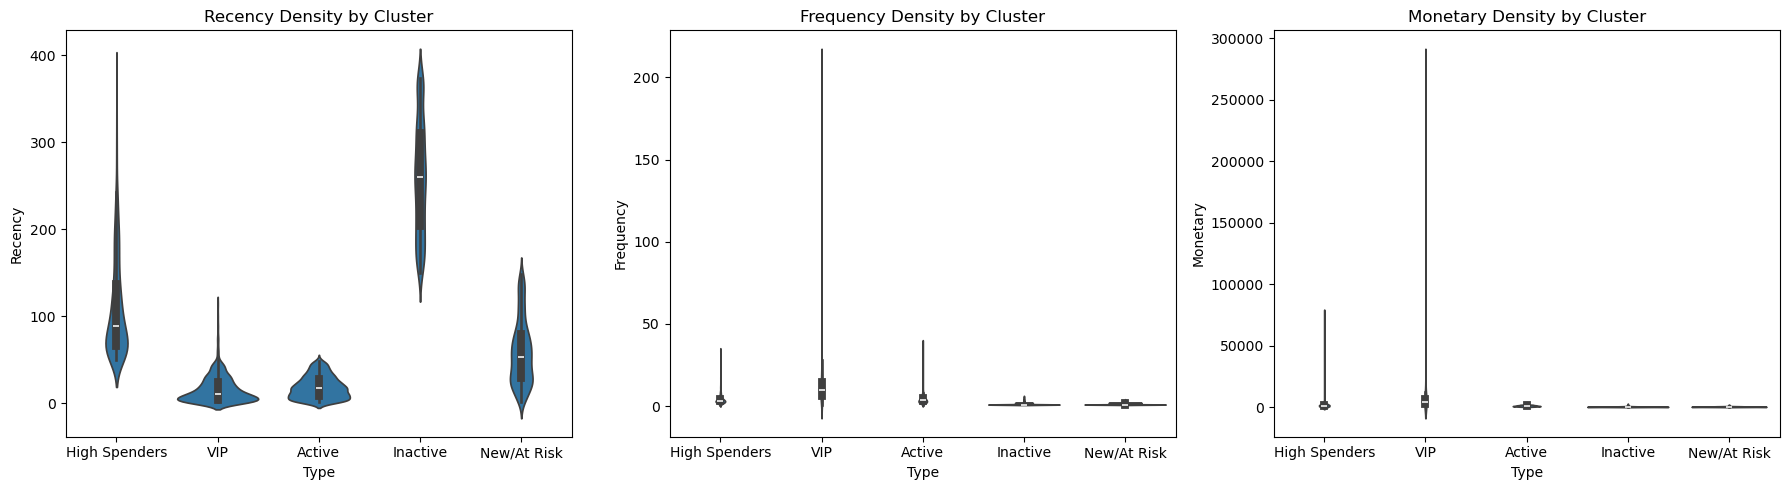

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.violinplot(data=rfm_customer, x='Type', y='Recency', ax=axes[0])
axes[0].set_title('Recency Density by Cluster')

sns.violinplot(data=rfm_customer, x='Type', y='Frequency', ax=axes[1])
axes[1].set_title('Frequency Density by Cluster')

sns.violinplot(data=rfm_customer, x='Type', y='Monetary', ax=axes[2])
axes[2].set_title('Monetary Density by Cluster')

plt.tight_layout()
plt.show()

### Revenue Share by each type of cluster

In [13]:
revenue_cluster = rfm_customer.groupby('Type')['Monetary'].sum().reset_index()
revenue_cluster.columns = ['Cluster-Type', 'TotalRevenue']
revenue_cluster['RevenueShare_%'] = (revenue_cluster['TotalRevenue'] / revenue_cluster['TotalRevenue'].sum() * 100).round(2)
revenue_cluster

,Cluster-Type,TotalRevenue,RevenueShare_%
0,Active,992249.741,11.16
1,High Spenders,1199839.412,13.50
2,Inactive,295127.380,3.32
3,New/At Risk,399026.051,4.49
4,VIP,6000966.310,67.52


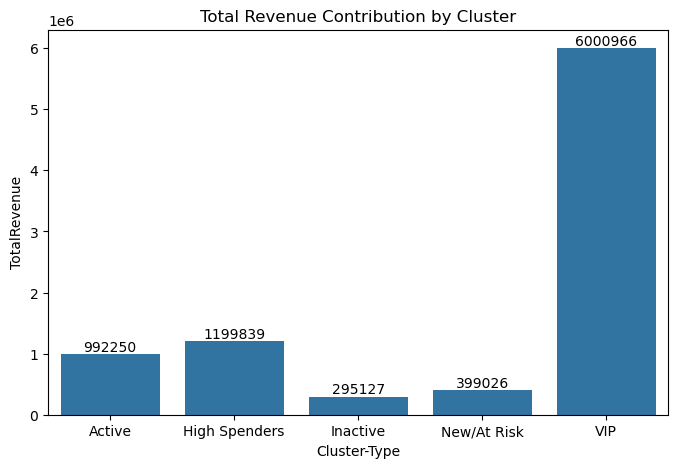

In [15]:
plt.figure(figsize=(8,5))
ax = sns.barplot(data=revenue_cluster, x='Cluster-Type', y='TotalRevenue')
for i in ax.containers:
    ax.bar_label(i, fmt='%.0f')
plt.title('Total Revenue Contribution by Cluster')
plt.show()

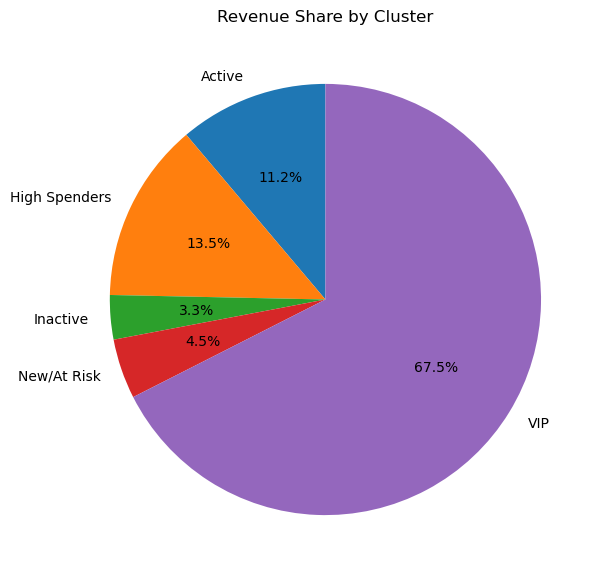

In [16]:
plt.figure(figsize=(7,7))
plt.pie(
    revenue_cluster['TotalRevenue'],
    labels=revenue_cluster['Cluster-Type'],
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Revenue Share by Cluster')
plt.show()

### Merge Transactions data with cluster

In [17]:
df_cluster = customers.merge(
    rfm_customer[['CustomerID', 'Cluster', 'Type']],
    on='CustomerID',
    how='left'
)

df_cluster.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSpend,InvoiceYearMonth,InvoiceDateOnly,InvoiceDayOfWeek,InvoiceHour,Cluster,Type
0,536365,85123A,white hanging heart t-light holder,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010-12,2010-12-01,Wednesday,8,2,High Spenders
1,536365,71053,white metal lantern,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,2010-12-01,Wednesday,8,2,High Spenders
2,536365,84406B,cream cupid hearts coat hanger,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010-12,2010-12-01,Wednesday,8,2,High Spenders
3,536365,84029G,knitted union flag hot water bottle,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,2010-12-01,Wednesday,8,2,High Spenders
4,536365,84029E,red woolly hottie white heart.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,2010-12-01,Wednesday,8,2,High Spenders


### calculate number of items per invoice and unique product

In [18]:
basket = df_cluster.groupby(
    ['CustomerID', 'InvoiceNo', 'Cluster', 'Type']
).agg(
    ItemsPerBasket=('Quantity', 'sum'),
    UniqueProducts=('Description', 'nunique')
).reset_index()

basket.head()

,CustomerID,InvoiceNo,Cluster,Type,ItemsPerBasket,UniqueProducts
0,12346,541431,2,High Spenders,74215,1
1,12347,537626,4,VIP,319,31
2,12347,542237,4,VIP,315,29
3,12347,549222,4,VIP,483,24
4,12347,556201,4,VIP,196,18


In [20]:
#verify the calculate above if it correct
customers[customers['InvoiceNo'] == 541431]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSpend,InvoiceYearMonth,InvoiceDateOnly,InvoiceDayOfWeek,InvoiceHour
36521,541431,23166,medium ceramic top storage jar,74215,2011-01-18 10:01:00,1.04,12346,United Kingdom,77183.6,2011-01,2011-01-18,Tuesday,10


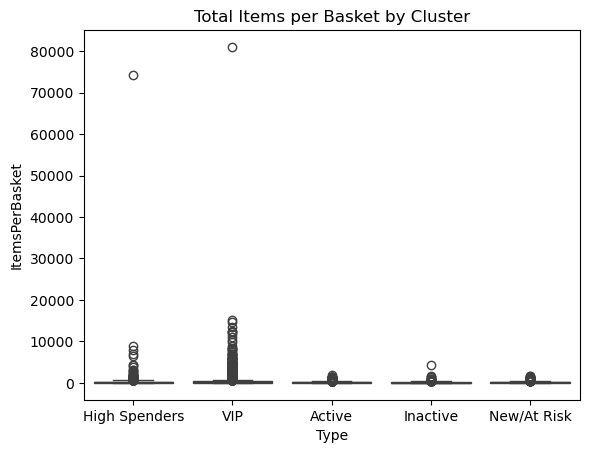

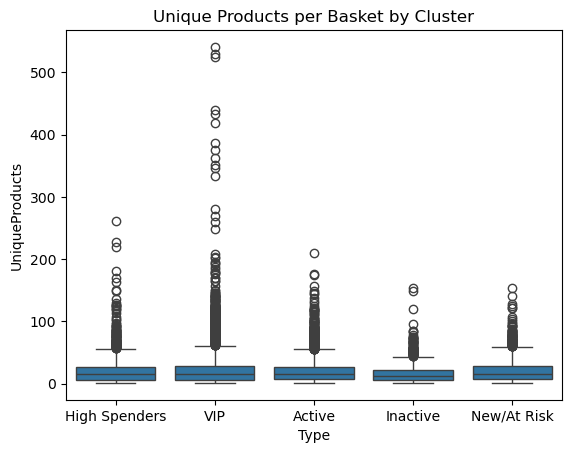

In [22]:
sns.boxplot(data=basket, x='Type', y='ItemsPerBasket')
plt.title('Total Items per Basket by Cluster')
plt.show()

sns.boxplot(data=basket, x='Type', y='UniqueProducts')
plt.title('Unique Products per Basket by Cluster')
plt.show()

In [25]:
basket_summary = basket.groupby('Type')[['ItemsPerBasket', 'UniqueProducts']].describe().round(2).T
basket_summary

Type                   Active  High Spenders  Inactive  New/At Risk       VIP
ItemsPerBasket count  3783.00        2701.00   1131.00      1442.00   9475.00
               mean    162.05         262.25    144.76       180.95    359.47
               std     157.26        1479.75    195.35       183.97   1090.98
               min       1.00           1.00      1.00         1.00      1.00
               25%      64.00          71.00     49.50        67.00     90.00
               50%     120.00         148.00     99.00       133.00    192.00
               75%     209.00         281.00    180.00       230.00    360.00
               max    1976.00       74215.00   4280.00      1728.00  80995.00
UniqueProducts count  3783.00        2701.00   1131.00      1442.00   9475.00
               mean     20.55          19.30     16.28        20.75     22.11
               std      19.99          20.04     16.14        19.71     27.19
               min       1.00           1.00      1.00         1.00      1.00
               25%       8.00           6.00      6.00         7.00      6.00
               50%      15.00          15.00     12.00        15.00     15.00
               75%      27.00          26.00     21.00        28.00     28.00
               max     210.00         262.00    153.00       154.00    541.00

### Spending on each cluster

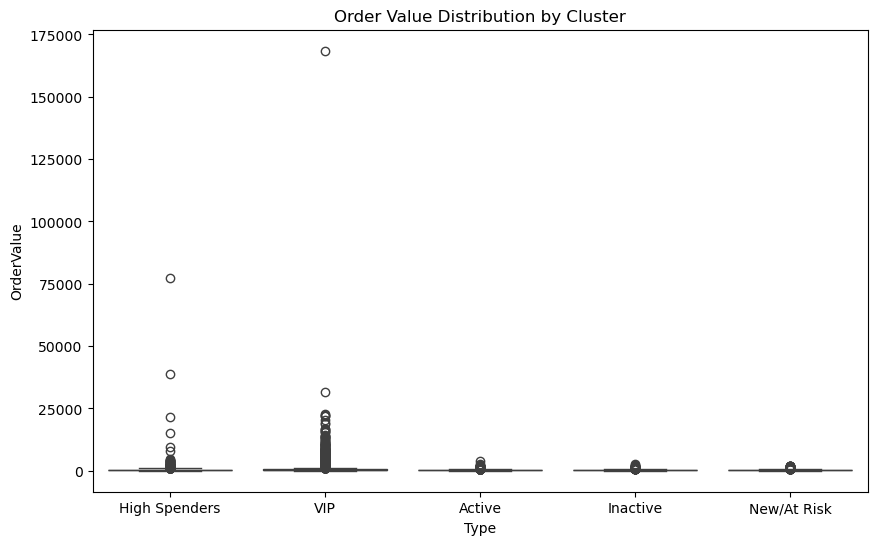

In [26]:
order_value = df_cluster.groupby(['CustomerID', 'InvoiceNo', 'Type'])['TotalSpend'].sum().reset_index()
order_value.rename(columns={'TotalSpend': 'OrderValue'}, inplace=True)

plt.figure(figsize=(10,6))
sns.boxplot(data=order_value, x='Type', y='OrderValue')
plt.title('Order Value Distribution by Cluster')
plt.show()

In [27]:
order_value.groupby('Type')['OrderValue'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
Type,,,,,,,,
Active,3783.0,262.29,213.30,0.40,134.36,215.76,327.76,3861.00
High Spenders,2701.0,444.22,1783.88,0.95,155.55,303.28,465.18,77183.60
Inactive,1131.0,260.94,250.13,1.90,116.00,195.13,321.35,2661.24
New/At Risk,1442.0,276.72,235.93,1.00,127.66,216.28,341.32,1862.00
VIP,9475.0,633.35,2124.18,0.38,202.94,348.32,603.87,168469.60


### Top Products by each cluster

In [35]:
top_products_cluster = (
    df_cluster.groupby(['Type', 'Description'])['Quantity']
    .sum()
    .reset_index()
    .sort_values(['Type', 'Quantity'], ascending=[True, False])
)

top_products_cluster.sample(20)

,Type,Description,Quantity
1703,Active,mobile vintage hearts,19
13169,VIP,home sweet home bottle,226
9615,New/At Risk,easter decoration natural chick,9
1002,Active,filigree heart butterfly white,160
5692,High Spenders,silicon star bulb blue,2
6785,Inactive,christmas tree decoration with bell,1
9187,New/At Risk,blue rose fabric mirror,37
860,Active,drawer knob vintage glass hexagon,81
1763,Active,number tile cottage garden 5,1
7032,Inactive,fairy cakes notebook a6 size,20


In [37]:
for c in sorted(df_cluster['Type'].dropna().unique()):
    print(f"\nTop 10 Products for Cluster : {c}")
    display(top_products_cluster[top_products_cluster['Type'] == c].head(10))


Top 10 Products for Cluster : Active


,Type,Description,Quantity
3128,Active,world war 2 gliders asstd designs,5424
170,Active,assorted colour bird ornament,4604
1443,Active,jumbo bag red retrospot,3391
440,Active,brocade ring purse,3268
2112,Active,popcorn holder,3249
2156,Active,rabbit night light,3117
3053,Active,white hanging heart t-light holder,2982
3104,Active,wooden heart christmas scandinavian,2876
150,Active,antique silver t-light glass,2861
1892,Active,paper chain kit 50's christmas,2847



Top 10 Products for Cluster : High Spenders


,Type,Description,Quantity
4749,High Spenders,medium ceramic top storage jar,74602
6108,High Spenders,white hanging heart t-light holder,7858
3368,High Spenders,assorted colours silk fan,7404
4095,High Spenders,fairy cake flannel assorted colour,6544
6178,High Spenders,world war 2 gliders asstd designs,6236
5228,High Spenders,popcorn holder,6102
4090,High Spenders,essential balm 3.5g tin in envelope,5674
4284,High Spenders,gin + tonic diet metal sign,4948
4981,High Spenders,pack of 72 retrospot cake cases,4386
4581,High Spenders,jumbo bag red retrospot,4351



Top 10 Products for Cluster : Inactive


,Type,Description,Quantity
8796,Inactive,world war 2 gliders asstd designs,3936
8035,Inactive,red harmonica in box,1670
8442,Inactive,small ceramic top storage jar,1487
6615,Inactive,brocade ring purse,1413
8734,Inactive,white hanging heart t-light holder,1296
6395,Inactive,assorted colours silk fan,1292
8647,Inactive,victorian glass hanging t-light,1252
7781,Inactive,pack of 72 retrospot cake cases,990
7637,Inactive,mini paint set vintage,936
7352,Inactive,heart of wicker small,896



Top 10 Products for Cluster : New/At Risk


,Type,Description,Quantity
11667,New/At Risk,world war 2 gliders asstd designs,2124
9020,New/At Risk,assorted laquered incense holders,2043
10735,New/At Risk,popart wooden pencils asst,1900
9859,New/At Risk,girls alphabet iron on patches,1728
11643,New/At Risk,wooden heart christmas scandinavian,1716
11650,New/At Risk,wooden star christmas scandinavian,1669
9007,New/At Risk,assorted colour bird ornament,1643
10126,New/At Risk,jumbo bag red retrospot,1428
8991,New/At Risk,antique silver t-light glass,1379
9231,New/At Risk,bubblegum ring assorted,1333



Top 10 Products for Cluster : VIP


,Type,Description,Quantity
13761,VIP,"paper craft , little birdie",80995
14007,VIP,popcorn holder,38433
15094,VIP,world war 2 gliders asstd designs,36599
13269,VIP,jumbo bag red retrospot,36426
13715,VIP,pack of 72 retrospot cake cases,24708
11914,VIP,assorted colour bird ornament,24006
15014,VIP,white hanging heart t-light holder,23445
14055,VIP,rabbit night light,23224
13682,VIP,pack of 12 london tissues,22580
13713,VIP,pack of 60 pink paisley cake cases,18898


In [38]:
product_diversity = df_cluster.groupby('Type')['Description'].nunique().reset_index()
product_diversity.columns = ['Type', 'UniqueProductsBought']
product_diversity

,Type,UniqueProductsBought
0,Active,3202
1,High Spenders,3044
2,Inactive,2604
3,New/At Risk,2876
4,VIP,3448


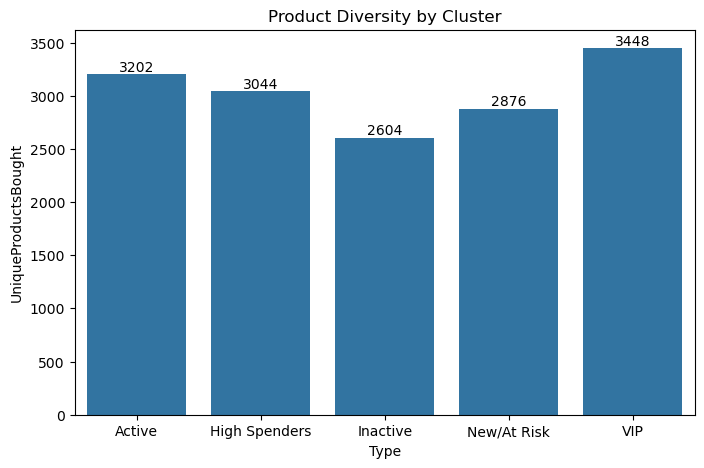

In [39]:
plt.figure(figsize=(8,5))
ax = sns.barplot(data=product_diversity, x='Type', y='UniqueProductsBought')
for i in ax.containers:
    ax.bar_label(i)
plt.title('Product Diversity by Cluster')
plt.show()

### Top Country

In [40]:
country_cluster = df_cluster.groupby(['Country', 'Type'])['CustomerID'].nunique().reset_index()
country_cluster.columns = ['Country', 'Type', 'UniqueCustomers']

top_countries = country_cluster.groupby('Country')['UniqueCustomers'].sum().nlargest(10).index
country_top = country_cluster[country_cluster['Country'].isin(top_countries)]

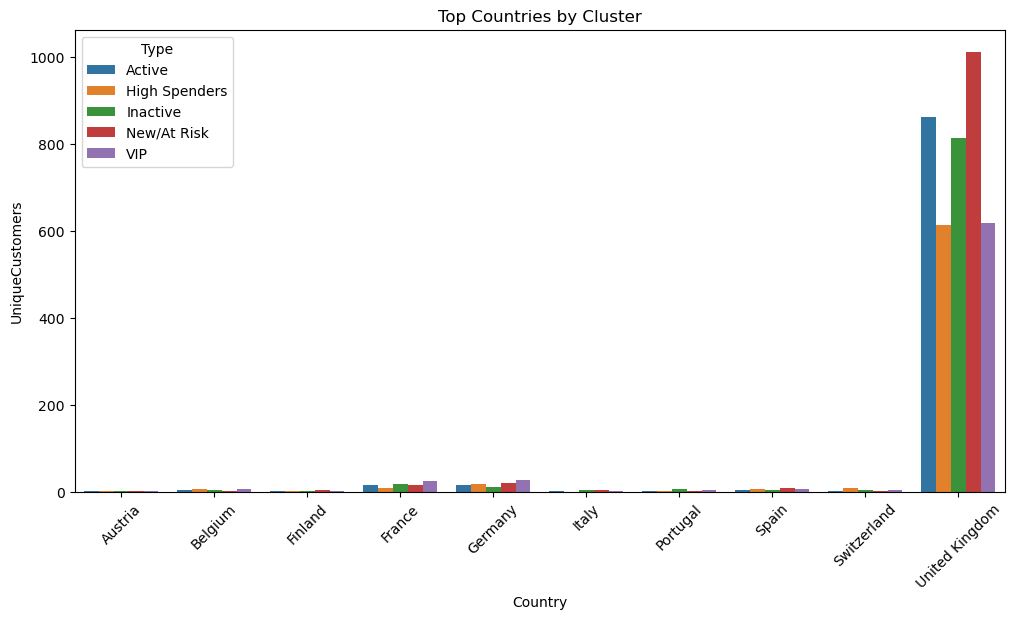

In [42]:
plt.figure(figsize=(12,6))
sns.barplot(data=country_top, x='Country', y='UniqueCustomers', hue='Type')
plt.title('Top Countries by Cluster')
plt.xticks(rotation=45)
plt.show()

### Monthly sales by each cluster

In [43]:
monthly_cluster_sales = df_cluster.groupby(['InvoiceYearMonth', 'Type'])['TotalSpend'].sum().reset_index()
monthly_cluster_sales.head()

,YearMonth,Type,TotalSpend
0,2010-12,Active,47535.77
1,2010-12,High Spenders,82759.46
2,2010-12,Inactive,45053.00
3,2010-12,New/At Risk,7319.21
4,2010-12,VIP,387755.29


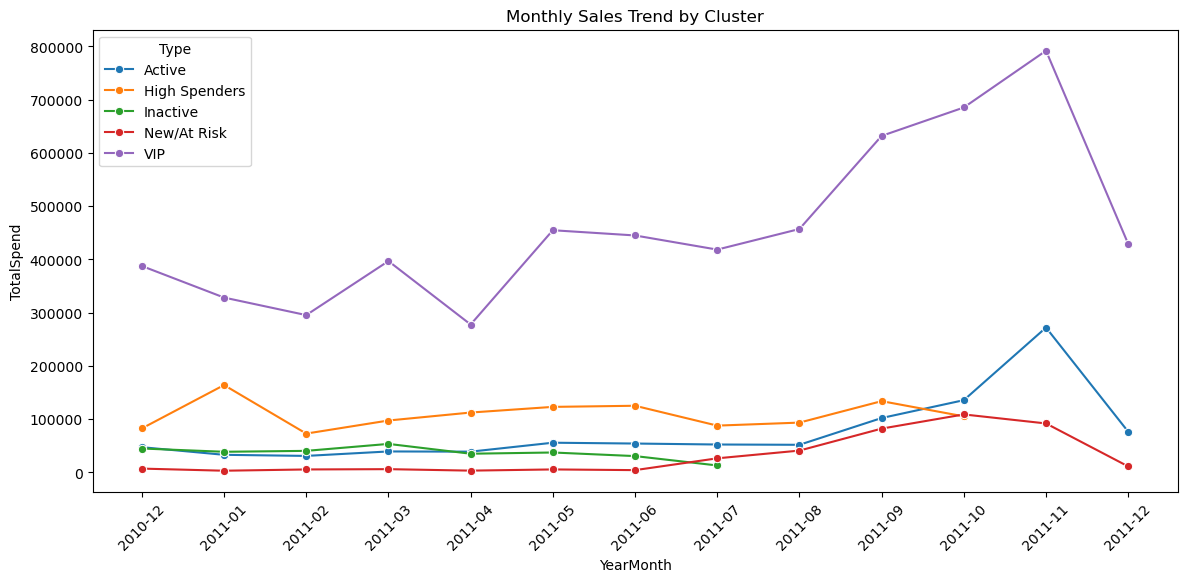

In [45]:
#line graph 

plt.figure(figsize=(14,6))
sns.lineplot(data=monthly_cluster_sales, x='InvoiceYearMonth', y='TotalSpend', hue='Type', marker='o')
plt.title('Monthly Sales Trend by Cluster')
plt.xticks(rotation=45)
plt.show()

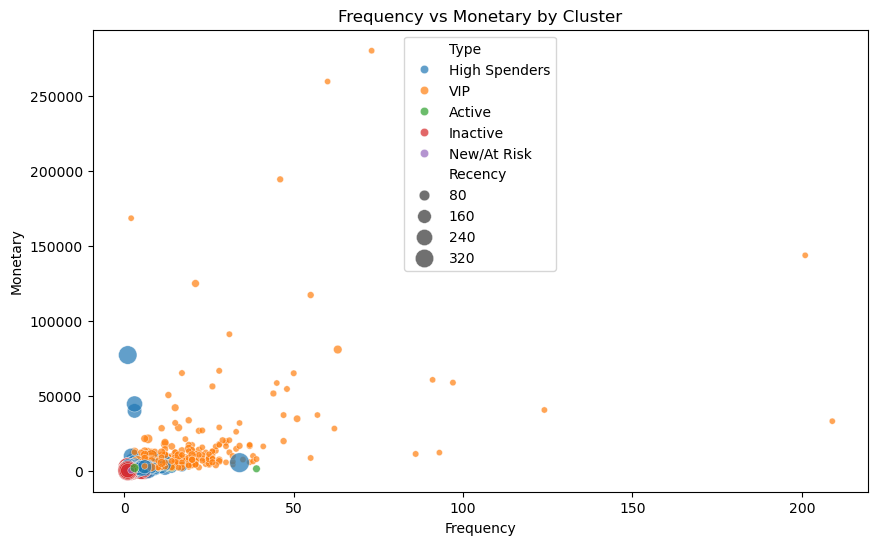

In [46]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=rfm_customer,
    x='Frequency',
    y='Monetary',
    hue='Type',
    size='Recency',
    sizes=(20, 200),
    alpha=0.7
)
plt.title('Frequency vs Monetary by Cluster')
plt.show()

### Transaction by each cluster of hours in a day and a week

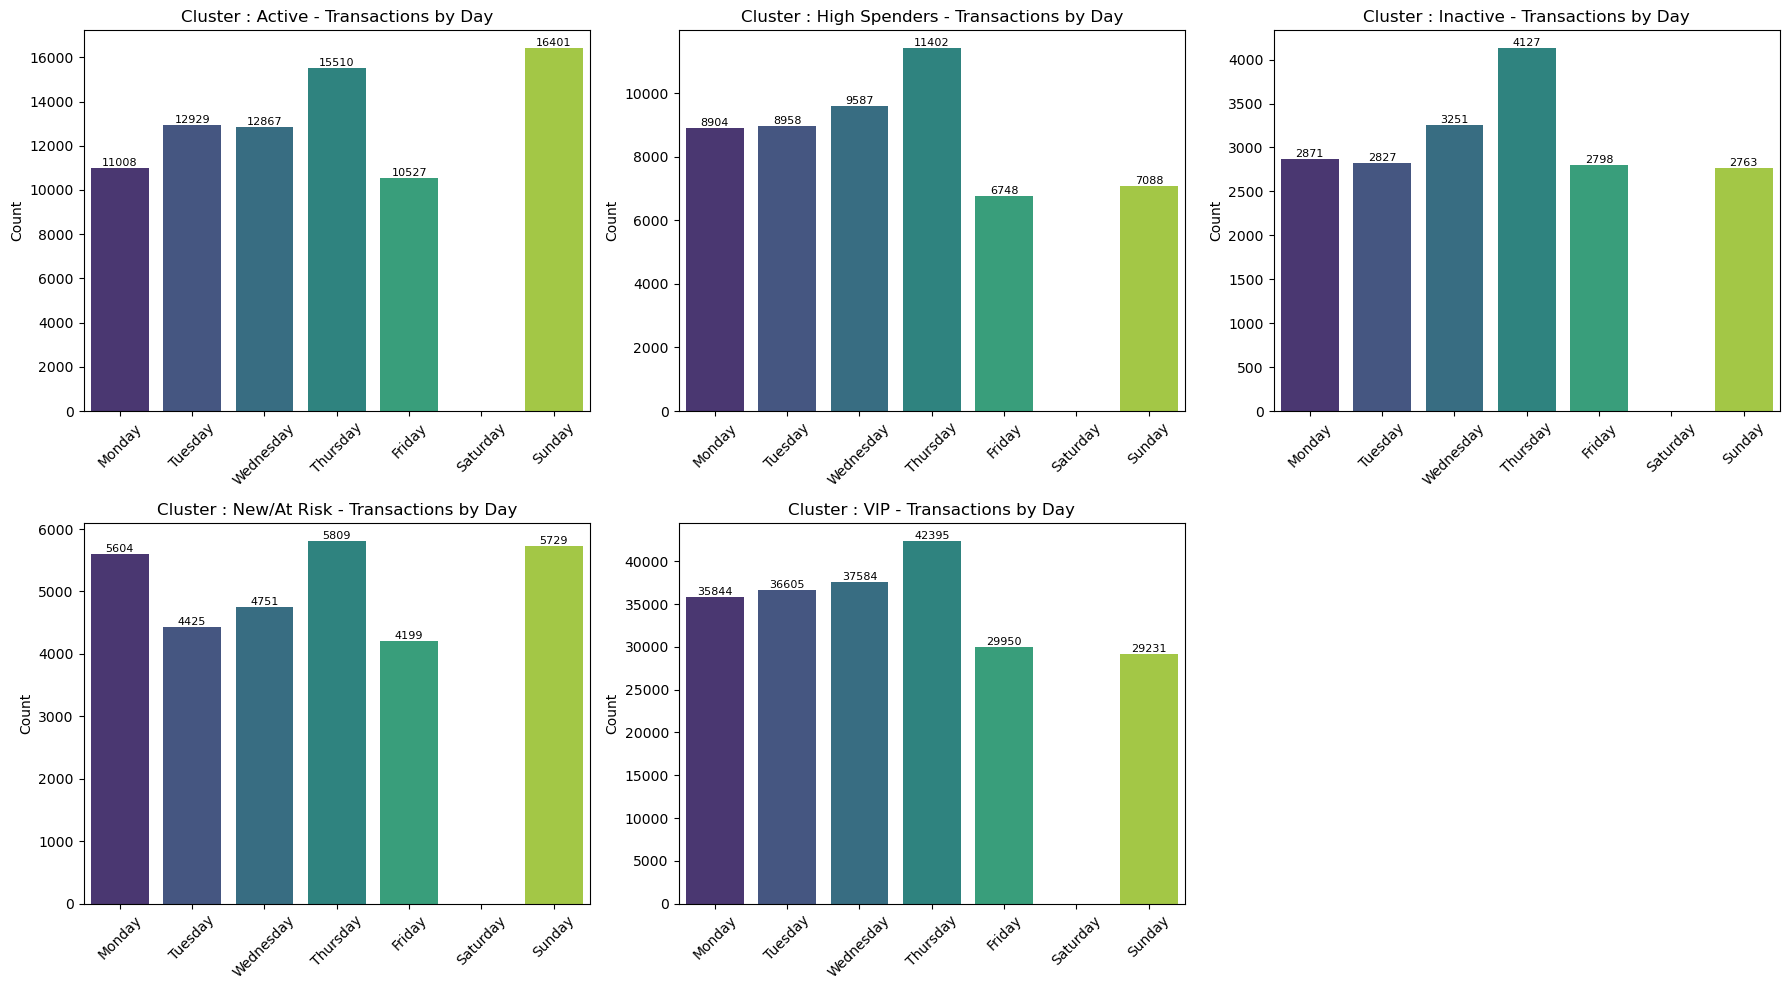

In [59]:
#bar graph of each cluster for transection of day of the week

dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

clusters = sorted(df_cluster['Type'].dropna().unique())

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, c in enumerate(clusters):
    subset = df_cluster[df_cluster['Type'] == c]
    
    dow_count = subset['InvoiceDayOfWeek'].value_counts().reindex(dow_order)
    
    ax = sns.barplot(
        x=dow_count.index,
        y=dow_count.values,
        palette='viridis',
        ax=axes[i]
    )
    
    axes[i].set_title(f'Cluster : {c} - Transactions by Day')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)
    
    # Add labels
    for container in ax.containers:
        ax.bar_label(container, fontsize=8)

# Remove empty plot
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

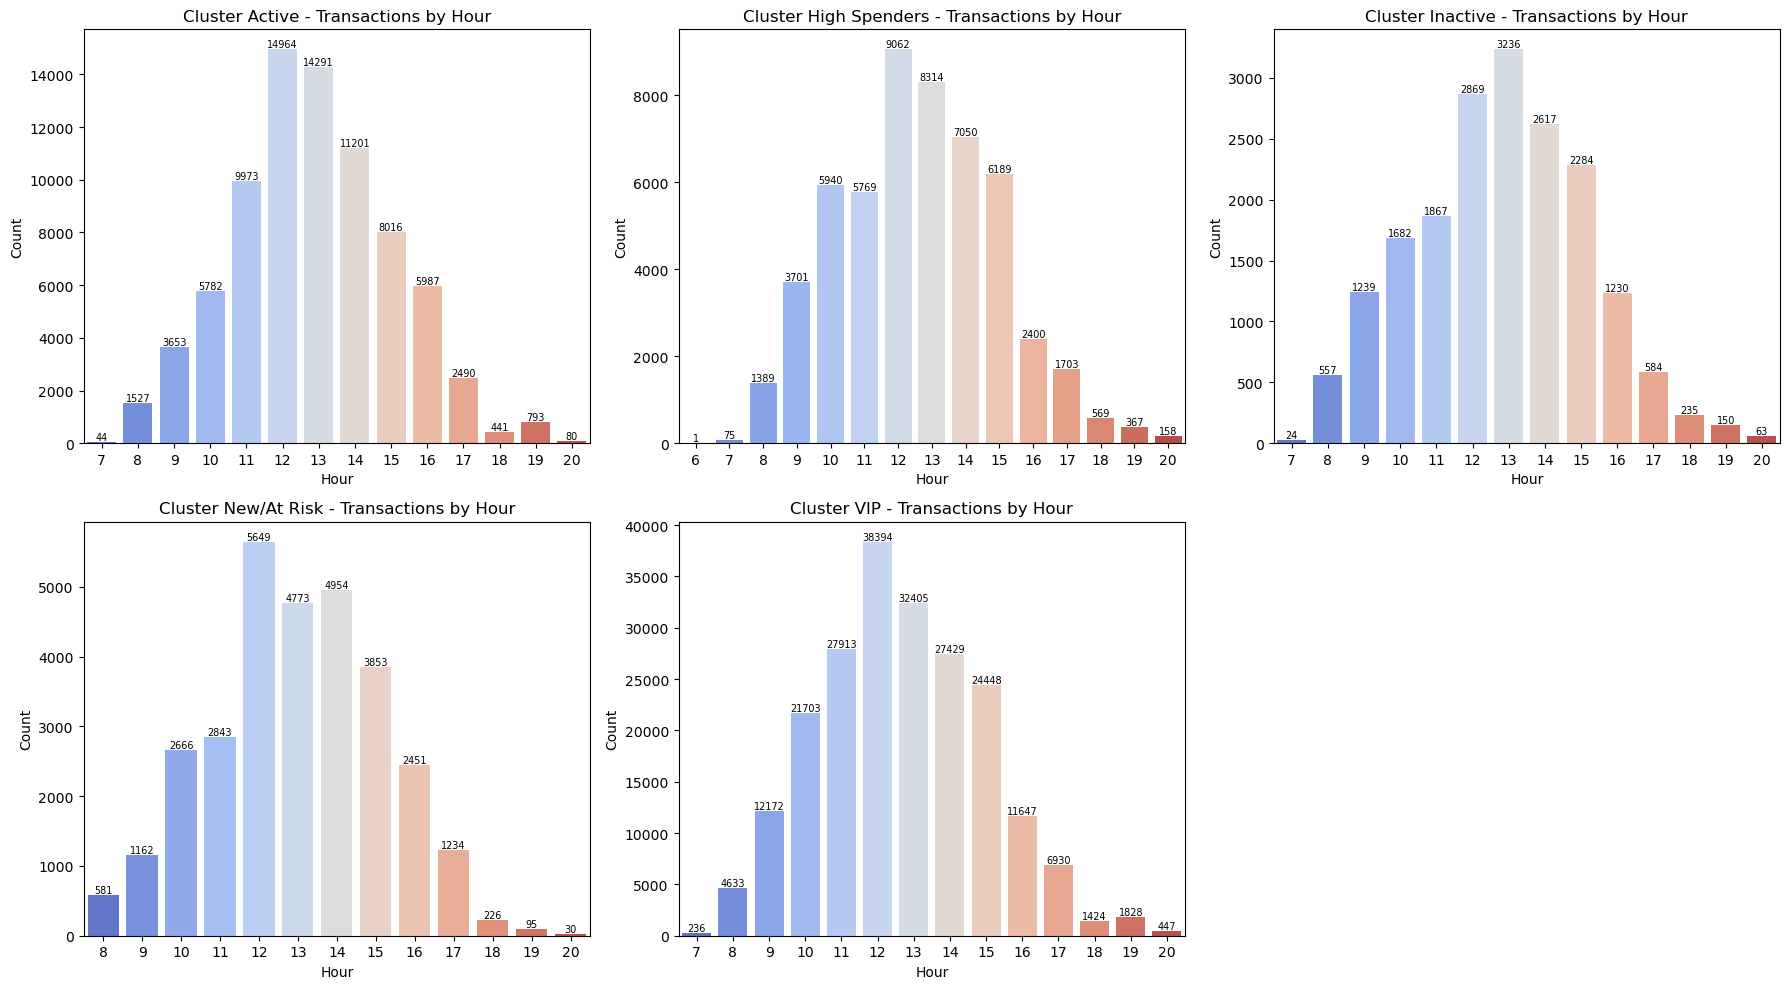

In [60]:
#bar graph hours of the day

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, c in enumerate(clusters):
    subset = df_cluster[df_cluster['Type'] == c]
    
    hour_count = subset['InvoiceHour'].value_counts().sort_index()
    
    ax = sns.barplot(
        x=hour_count.index,
        y=hour_count.values,
        palette='coolwarm',
        ax=axes[i]
    )
    
    axes[i].set_title(f'Cluster {c} - Transactions by Hour')
    axes[i].set_xlabel('Hour')
    axes[i].set_ylabel('Count')
    
    # Add labels
    for container in ax.containers:
        ax.bar_label(container, fontsize=7)

# Remove empty plot
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

### Correlation Matrix for each cluster of RFM

In [47]:
for c in sorted(rfm_customer['Type'].unique()):
    subset = rfm_customer[rfm_customer['Type'] == c][['Recency', 'Frequency', 'Monetary']]
    print(f"\nCorrelation matrix for Cluster : {c}")
    display(subset.corr().round(2))


Correlation matrix for Cluster : Active


,Recency,Frequency,Monetary
Recency,1.00,-0.08,0.00
Frequency,-0.08,1.00,0.36
Monetary,0.00,0.36,1.00



Correlation matrix for Cluster : High Spenders


,Recency,Frequency,Monetary
Recency,1.00,-0.04,0.16
Frequency,-0.04,1.00,0.05
Monetary,0.16,0.05,1.00



Correlation matrix for Cluster : Inactive


,Recency,Frequency,Monetary
Recency,1.00,-0.19,0.01
Frequency,-0.19,1.00,0.13
Monetary,0.01,0.13,1.00



Correlation matrix for Cluster : New/At Risk


,Recency,Frequency,Monetary
Recency,1.00,-0.00,0.15
Frequency,-0.00,1.00,0.06
Monetary,0.15,0.06,1.00



Correlation matrix for Cluster : VIP


,Recency,Frequency,Monetary
Recency,1.00,-0.24,-0.11
Frequency,-0.24,1.00,0.50
Monetary,-0.11,0.50,1.00


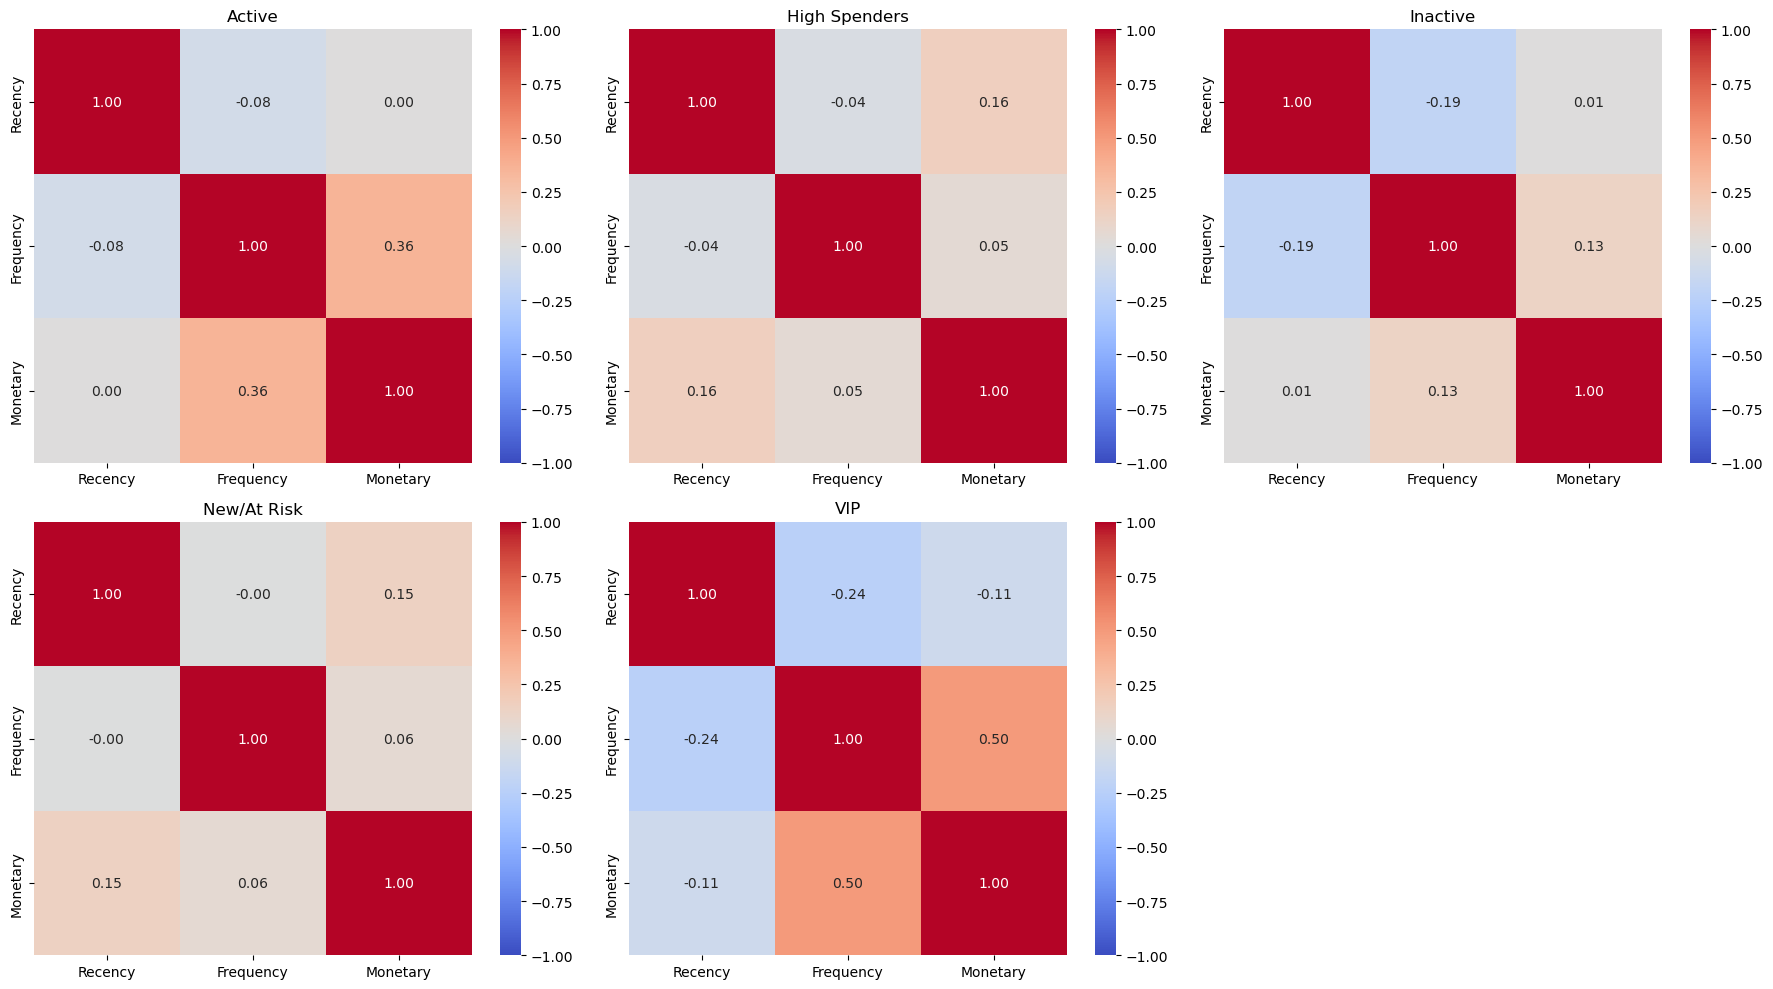

In [48]:
types = sorted(rfm_customer['Type'].dropna().unique())

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()  # make indexing easier

for i, t in enumerate(types):
    subset = rfm_customer[rfm_customer['Type'] == t][['Recency', 'Frequency', 'Monetary']]
    
    corr = subset.corr()
    
    sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        cmap='coolwarm',
        vmin=-1, vmax=1,
        ax=axes[i]
    )
    
    axes[i].set_title(f"{t}")

# Remove empty subplot (since 5 plots in 6 slots)
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

### Top 5 customers by each cluster

In [50]:
for c in sorted(rfm_customer['Type'].unique()):
    print(f"\nTop 5 customers in Cluster : {c} by Monetary")
    display(
        rfm_customer[rfm_customer['Type'] == c]
        .sort_values('Monetary', ascending=False)
        .head(5)
    )


Top 5 customers in Cluster : Active by Monetary


,CustomerID,Recency,Frequency,Monetary,RScore,FScore,MScore,Cluster,Description,Type
2087,15195,3,1,3861.00,5,1,4,0,Very recent customers with moderate purchase f...,Active
2860,16240,24,2,3718.80,4,2,4,0,Very recent customers with moderate purchase f...,Active
47,12406,22,2,3415.30,4,2,4,0,Very recent customers with moderate purchase f...,Active
1123,13868,7,2,3192.54,5,2,4,0,Very recent customers with moderate purchase f...,Active
76,12438,14,2,2906.85,5,2,4,0,Very recent customers with moderate purchase f...,Active



Top 5 customers in Cluster : High Spenders by Monetary


,CustomerID,Recency,Frequency,Monetary,RScore,FScore,MScore,Cluster,Description,Type
0,12346,326,1,77183.60,1,1,5,2,Moderately recent customers with good spending...,High Spenders
2502,15749,235,3,44534.30,2,3,5,2,Moderately recent customers with good spending...,High Spenders
2011,15098,182,3,39916.50,2,3,5,2,Moderately recent customers with good spending...,High Spenders
196,12590,211,2,9864.26,2,2,5,2,Moderately recent customers with good spending...,High Spenders
566,13093,276,8,7832.47,1,3,5,2,Moderately recent customers with good spending...,High Spenders



Top 5 customers in Cluster : Inactive by Monetary


,CustomerID,Recency,Frequency,Monetary,RScore,FScore,MScore,Cluster,Description,Type
1533,14439,320,1,2661.24,1,1,4,1,Old customers with very low frequency and low ...,Inactive
123,12501,337,1,2169.39,1,1,4,1,Old customers with very low frequency and low ...,Inactive
3230,16754,372,1,2002.40,1,1,4,1,Old customers with very low frequency and low ...,Inactive
1548,14459,155,1,1837.92,2,1,3,1,Old customers with very low frequency and low ...,Inactive
2793,16152,269,1,1829.04,1,1,3,1,Old customers with very low frequency and low ...,Inactive



Top 5 customers in Cluster : New/At Risk by Monetary


,CustomerID,Recency,Frequency,Monetary,RScore,FScore,MScore,Cluster,Description,Type
1860,14887,79,1,1862.00,3,1,3,3,Recent customers with very low frequency and s...,New/At Risk
3227,16751,31,1,1764.72,4,1,3,3,Recent customers with very low frequency and s...,New/At Risk
2960,16380,61,1,1743.15,3,1,3,3,Recent customers with very low frequency and s...,New/At Risk
1051,13763,63,1,1714.96,3,1,3,3,Recent customers with very low frequency and s...,New/At Risk
46,12405,149,1,1710.39,3,1,3,3,Recent customers with very low frequency and s...,New/At Risk



Top 5 customers in Cluster : VIP by Monetary


,CustomerID,Recency,Frequency,Monetary,RScore,FScore,MScore,Cluster,Description,Type
1689,14646,2,73,280206.02,5,5,5,4,"Highly valuable customers: very recent, freque...",VIP
4201,18102,1,60,259657.30,5,5,5,4,"Highly valuable customers: very recent, freque...",VIP
3728,17450,8,46,194390.79,5,4,5,4,"Highly valuable customers: very recent, freque...",VIP
3008,16446,1,2,168472.50,5,2,5,4,"Highly valuable customers: very recent, freque...",VIP
1879,14911,1,201,143711.17,5,5,5,4,"Highly valuable customers: very recent, freque...",VIP


### KPI: Key performance indicator Table

In [56]:
kpi_table = rfm_customer.groupby(['Cluster', 'Type', 'Description']).agg(
    Customers=('CustomerID', 'nunique'),
    AvgRecency=('Recency', 'mean'),
    MedianRecency=('Recency', 'median'),
    AvgFrequency=('Frequency', 'mean'),
    MedianFrequency=('Frequency', 'median'),
    AvgMonetary=('Monetary', 'mean'),
    MedianMonetary=('Monetary', 'median'),
    TotalRevenue=('Monetary', 'sum')
).round(2).reset_index()

kpi_table['RevenueShare_%'] = (kpi_table['TotalRevenue'] / kpi_table['TotalRevenue'].sum() * 100).round(2)
kpi_table

,Cluster,Type,Description,Customers,AvgRecency,MedianRecency,AvgFrequency,MedianFrequency,AvgMonetary,MedianMonetary,TotalRevenue,RevenueShare_%
0,0,Active,Very recent customers with moderate purchase f...,929,18.63,17.0,4.07,4.0,1068.08,1005.09,992249.74,11.16
1,1,Inactive,Old customers with very low frequency and low ...,893,258.88,260.0,1.27,1.0,330.49,266.40,295127.38,3.32
2,2,High Spenders,Moderately recent customers with good spending...,695,109.92,89.0,3.89,3.0,1726.39,1143.27,1199839.41,13.50
3,3,New/At Risk,Recent customers with very low frequency and s...,1103,58.93,53.0,1.31,1.0,361.76,305.54,399026.05,4.49
4,4,VIP,"Highly valuable customers: very recent, freque...",718,16.07,11.0,13.20,10.0,8357.89,3959.45,6000966.31,67.52


In [57]:
for _, row in kpi_table.iterrows():
    print(f"""
Cluster {int(row['Cluster'])} - {row['Type']}
Description: {row['Description']}
Customers: {row['Customers']}
Avg Recency: {row['AvgRecency']}
Avg Frequency: {row['AvgFrequency']}
Avg Monetary: {row['AvgMonetary']}
Revenue Share: {row['RevenueShare_%']}%
""")


Cluster 0 - Active
Description: Very recent customers with moderate purchase frequency and spending
Customers: 929
Avg Recency: 18.63
Avg Frequency: 4.07
Avg Monetary: 1068.08
Revenue Share: 11.16%


Cluster 1 - Inactive
Description: Old customers with very low frequency and low spending (inactive/lost)
Customers: 893
Avg Recency: 258.88
Avg Frequency: 1.27
Avg Monetary: 330.49
Revenue Share: 3.32%


Cluster 2 - High Spenders
Description: Moderately recent customers with good spending but average frequency
Customers: 695
Avg Recency: 109.92
Avg Frequency: 3.89
Avg Monetary: 1726.39
Revenue Share: 13.5%


Cluster 3 - New/At Risk
Description: Recent customers with very low frequency and spending (one-time or disengaging)
Customers: 1103
Avg Recency: 58.93
Avg Frequency: 1.31
Avg Monetary: 361.76
Revenue Share: 4.49%


Cluster 4 - VIP
Description: Highly valuable customers: very recent, frequent, and high spending
Customers: 718
Avg Recency: 16.07
Avg Frequency: 13.2
Avg Monetary: 8357.8